# Basic demonstration of fUSi analysis

This notebook is designed to demonstrate the process of loading functional ultrasound imaging (fUSi) data and associated behavioral metadata. It outlines the steps to preprocess the data, generate statistical parametric maps, and extract time series data from regions of interest (ROIs).

Note that this notebook is built around the dataset collected with UCLA after applying SSEPs and is only running a single run at a time. We'll need fancier approaches to integrate multiple runs, or run more interesting comparisons between multiple conditions


Ultimetly we get something like the figure below, which shows us the stastically significant regions of the fUSi data as well as the corresponding time series data for each ROI.




In [1]:
%load_ext autoreload
%autoreload 2
from nilearn import plotting
from scipy.io import savemat


import nilearn as nl
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import os
import pandas as pd
import re

from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

from ucla_fusi_utils import DirectoryManager
import ucla_fusi_utils as utils


from pathlib import Path
from datetime import datetime, timedelta

from anise.io.load_matlab_dataset import load_data, load_selected_data



In [2]:
# define arguements to specify the data to be processed
base_path=Path('/Users/clairenastaskin/data/2024-10-23/UCLA-008/Functional_runs/run-01/')
sequence = 'seq-IQ_3D_2cmto3cm_Depth_5MHz_1a_3c_200loops_-1Gain_2rp'
dm = DirectoryManager(base_path, sequence)
dm.list_acquisition_directories()
dm.print_paths()

# Change power doppler path if needed
dm.power_doppler_path = base_path / 'acquisitions' / sequence / 'power_doppler'

print(dm.power_doppler_path)


event_time_offset = 0 # Offset in seconds to apply to stimulus onsets. This can be used to correct for differences between when the instruction is given and when the stimulus is presented.
apply_image_registration=True # If true, we will register the fUSi data to the first frame. If false, we will not register the fUSi data.
time_zone_offset=0
smoothing_fwhm=0.3 #0 spatial smoothing in mm to apply to the data before computing GLM
num_locations=4 # How many ROIs to visualize

/Users/clairenastaskin/data/2024-10-23/UCLA-008/Functional_runs/run-01/acquisitions/seq-IQ_3D_2cmto3cm_Depth_5MHz_1a_3c_200loops_-1Gain_2rp/fUSI
Directories in acquisitions path:
    seq-IQ_3D_2cmto3cm_Depth_5MHz_1a_3c_200loops_-1Gain_2rp
List of all directories in acquisitions path:
    log_file_path: /Users/clairenastaskin/data/2024-10-23/UCLA-008/Functional_runs/run-01/logs/task.log
    task_event_file_path: /Users/clairenastaskin/data/2024-10-23/UCLA-008/Functional_runs/run-01/streams/task-event_stream.h5
    probe_event_file_path: /Users/clairenastaskin/data/2024-10-23/UCLA-008/Functional_runs/run-01/streams/probe-event_stream.h5
    sequence_data_path: /Users/clairenastaskin/data/2024-10-23/UCLA-008/Functional_runs/run-01/acquisitions/seq-IQ_3D_2cmto3cm_Depth_5MHz_1a_3c_200loops_-1Gain_2rp
    raw_data_path: /Users/clairenastaskin/data/2024-10-23/UCLA-008/Functional_runs/run-01/acquisitions/seq-IQ_3D_2cmto3cm_Depth_5MHz_1a_3c_200loops_-1Gain_2rp/raw_frame_data
    beamformed_path

In [3]:
# Create the events data structure to create a design matrix
fusi_info=utils.load_fUSi_info(dm.power_doppler_path,num_tissue_components=60)
task_info = utils.extract_events_from_h5(dm.task_event_file_path)
task_events=utils.calculate_stimulus_events_daq(task_info)
probe_events=utils.extract_probe_events_from_h5(dm.probe_event_file_path,sequence)
task_events['onset'] += event_time_offset
print(task_events)

['ensemble_2024-10-23T16-13-03-105786-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-10-23T16-13-11-868915-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-10-23T16-12-28-108579-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-10-23T16-12-22-117648-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-10-23T16-14-19-194355-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-10-23T16-15-18-424953-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-10-23T16-14-01-576194-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=60.h5', 'ensemble_2024-10-23T16-14-28-066557-pixel_size_wavelengths=0.5-num_blood_and_tiss

Convert the pandas data structure into something importable to nilearn


(188, 172, 74, 118)


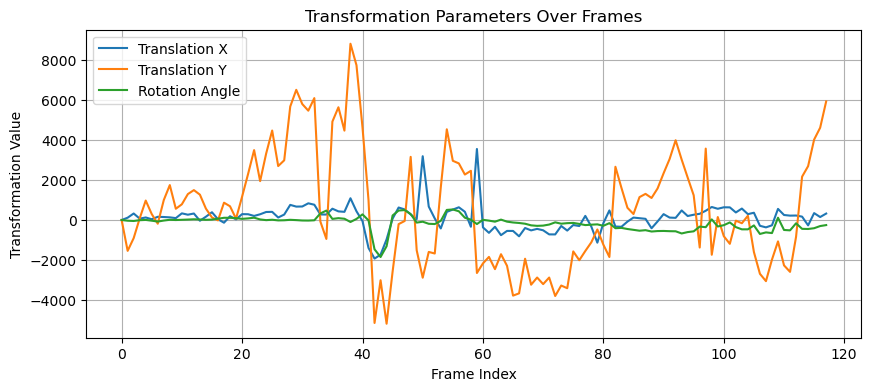

In [4]:
#############################################################################
# If needed: perform image registration and display transformation dynamic  #
#############################################################################

# get fusi data
# frame_indices specifies with power doppler frames to read in. This would be a list e.g. [0,1,2,3...] or just use -1 to specify all
frame_indices = -1  # Generates [0, 1, 2, ..., 39] # Specify the frame indices you want to import
fusi_data = utils.get_fusi_frames(dm.power_doppler_path, fusi_info, frame_indices)
print(fusi_data.shape)

plot_transformations=True
if apply_image_registration:
    fusi_data_3d_reg,transformations=utils.register_3d_image_stack(fusi_data)
    # fusi_data_3d_reg,transformations=utils.register_ants(fusi_data_3d)

    fusi_data = np.tile(fusi_data_3d_reg, (1, 2, 1, 1))
    if plot_transformations:
        plt.figure(figsize=(10, 4))
        plt.plot(transformations[0, :]*1000, label='Translation X')
        plt.plot(transformations[1, :]*1000, label='Translation Y')
        plt.plot(transformations[2, :]*180/np.pi, label='Rotation Angle')

        
        plt.title('Transformation Parameters Over Frames')
        plt.xlabel('Frame Index')
        plt.ylabel('Transformation Value')
        plt.legend()
        plt.grid(True)
        plt.show()


Text(0, 0.5, 'Average Intensity')

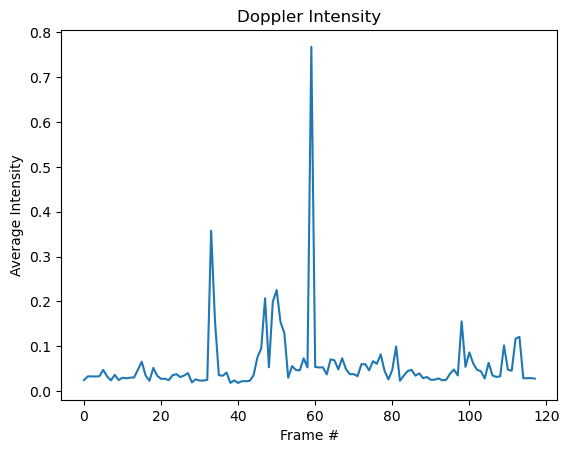

In [5]:
#########################################
#     Plot average Doppler over time    #
#########################################

average_over_time = np.mean(fusi_data, axis=(0, 1, 2))
plt.plot(average_over_time)
plt.title('Doppler Intensity')
plt.xlabel('Frame #')
plt.ylabel('Average Intensity')

[33, 34, 47, 49, 50, 51, 52, 59, 98]
(3, 109)


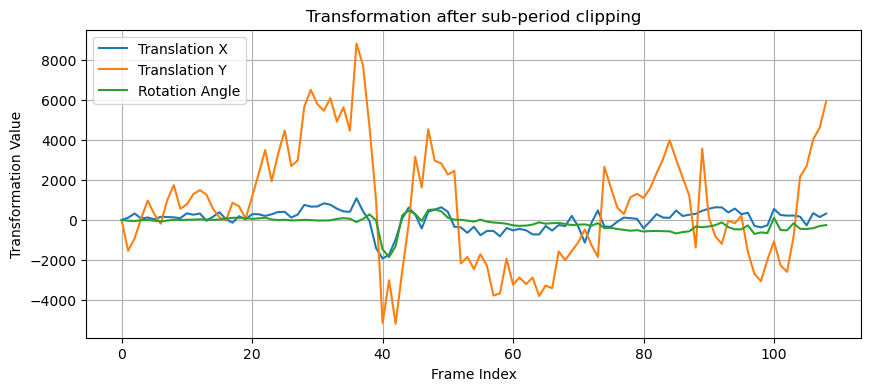

Text(0, 0.5, 'Average Intensity')

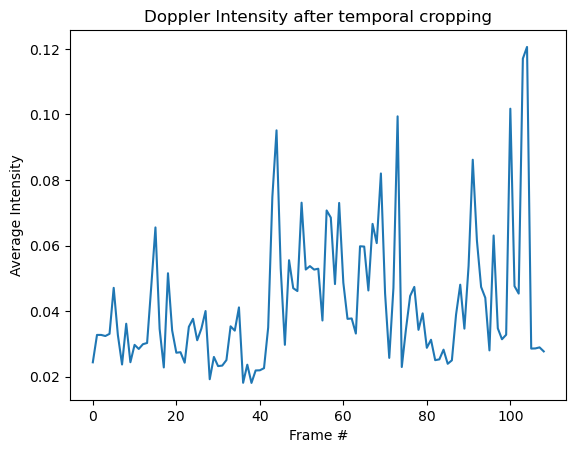

In [6]:
#################################
#     Remove extreme outliers    #
##################################

remove_extreme_outliers = True
# Define a quite time period to compare to
quite_time_period = [0, 30]

mean_quite_time_period = np.mean(average_over_time[quite_time_period[0]:quite_time_period[1]])
std_quite_time_period = np.std(average_over_time[quite_time_period[0]:quite_time_period[1]])

skip_frames = []
for i in range(fusi_data.shape[3]):
    if np.abs(average_over_time[i] - mean_quite_time_period) > 10*std_quite_time_period:
        skip_frames = skip_frames + [i]
print(skip_frames)

frames_to_keep = [i for i in range(fusi_data.shape[3]) if i not in skip_frames]

 # Sub-period of fusi_data
fusi_data_sub_period = fusi_data[:, :, :, frames_to_keep]
fusi_info_sub_period = fusi_info.iloc[frames_to_keep]
# Select a sub-period of probe_events based on indices
probe_events_sub_period = probe_events.iloc[frames_to_keep].reset_index(drop=True)

# Filter task_info based on the sub-period range for time_stamp data of probe_events_sub_period
task_events_sub = task_events[
    (task_events['onset'] >= probe_events_sub_period.time_stamp.iloc[0]) &
    (task_events['onset'] <= probe_events_sub_period.time_stamp.iloc[-1])  # iloc[-1] for last value
].reset_index(drop=True)

if apply_image_registration:

    # Sub-period of transformations
    transformations_sub_period = transformations[:, frames_to_keep]
    print(transformations_sub_period.shape)

    plt.figure(figsize=(10, 4))
    plt.plot(transformations_sub_period[0, :]*1000, label='Translation X')
    plt.plot(transformations_sub_period[1, :]*1000, label='Translation Y')
    plt.plot(transformations_sub_period[2, :]*180/np.pi, label='Rotation Angle')
    plt.title('Transformation after sub-period clipping')
    plt.xlabel('Frame Index')
    plt.ylabel('Transformation Value')
    plt.legend()
    plt.grid(True)
    plt.show()


average_over_time_sub_period = np.mean(fusi_data_sub_period, axis=(0, 1, 2))
plt.plot(average_over_time_sub_period)
plt.title('Doppler Intensity after temporal cropping')
plt.xlabel('Frame #')
plt.ylabel('Average Intensity')

In [7]:
###############################################################################################
#     Depending on the transformation matrix, we can select a sub-period of time to study     #
###############################################################################################

study_sub_period = False
sub_period_to_study = [0, 75]

if study_sub_period:
    # Sub-period of fusi_data
    fusi_data_sub_period = fusi_data[:, :, :, sub_period_to_study[0]:sub_period_to_study[1]]
    fusi_info_sub_period = fusi_info[sub_period_to_study[0]:sub_period_to_study[1]]
   # Select a sub-period of probe_events based on indices
    probe_events_sub_period = probe_events.iloc[sub_period_to_study[0]:sub_period_to_study[1]].reset_index(drop=True)

   # Filter task_info based on the sub-period range for time_stamp data of probe_events_sub_period
    task_events_sub = task_events[
        (task_events['onset'] >= probe_events_sub_period.time_stamp.iloc[0]) &
        (task_events['onset'] <= probe_events_sub_period.time_stamp.iloc[-1])  # iloc[-1] for last value
    ].reset_index(drop=True)

    # print(task_info_sub.shape)
    if apply_image_registration:

        # Sub-period of transformations
        transformations_sub_period = transformations[:, sub_period_to_study[0]:sub_period_to_study[1]]
        print(transformations_sub_period.shape)

        plt.figure(figsize=(10, 4))
        plt.plot(transformations_sub_period[0, :]*1000, label='Translation X')
        plt.plot(transformations_sub_period[1, :]*1000, label='Translation Y')
        plt.plot(transformations_sub_period[2, :]*180/np.pi, label='Rotation Angle')
        plt.title('Transformation after sub-period clipping')
        plt.xlabel('Frame Index')
        plt.ylabel('Transformation Value')
        plt.legend()
        plt.grid(True)
        plt.show()


    average_over_time_sub_period = np.mean(fusi_data_sub_period, axis=(0, 1, 2))
    plt.plot(average_over_time_sub_period)
    plt.title('Doppler Intensity after temporal cropping')
    plt.xlabel('Frame #')
    plt.ylabel('Average Intensity')

In [8]:
transformations=transformations_sub_period
print("Transformations shape:", transformations.shape)
print("Number of time frames:", len(probe_events['time_stamp']))

Transformations shape: (3, 109)
Number of time frames: 118


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_16141/1083826499.py:33: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



<Figure size 640x480 with 0 Axes>

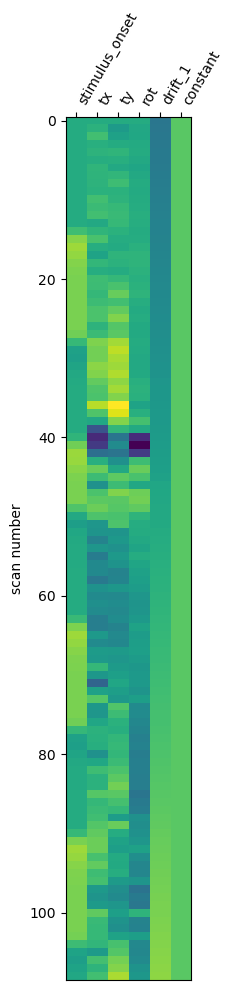

In [9]:
#######################################
#     Create design matrix for GLM    #
#######################################
if study_sub_period or remove_extreme_outliers:
    fusi_info=fusi_info_sub_period
    fusi_data=fusi_data_sub_period
    probe_events=probe_events_sub_period
    task_events=task_events_sub
    transformations=transformations_sub_period

hrf_model = "glover"
if apply_image_registration:
    design_matrix = make_first_level_design_matrix(
        probe_events['time_stamp'] ,
        task_events,
        drift_model="polynomial",
        drift_order=1,
        add_regs=transformations.transpose(),
        add_reg_names=["tx","ty","rot"],
        hrf_model=hrf_model,
    )
else:
    design_matrix = make_first_level_design_matrix(
        probe_events['time_stamp'] ,
        task_events,
        drift_model="polynomial",
        drift_order=1,
        hrf_model=hrf_model,
    )

fig = plt.figure()
plot_design_matrix(design_matrix)
fig.show()

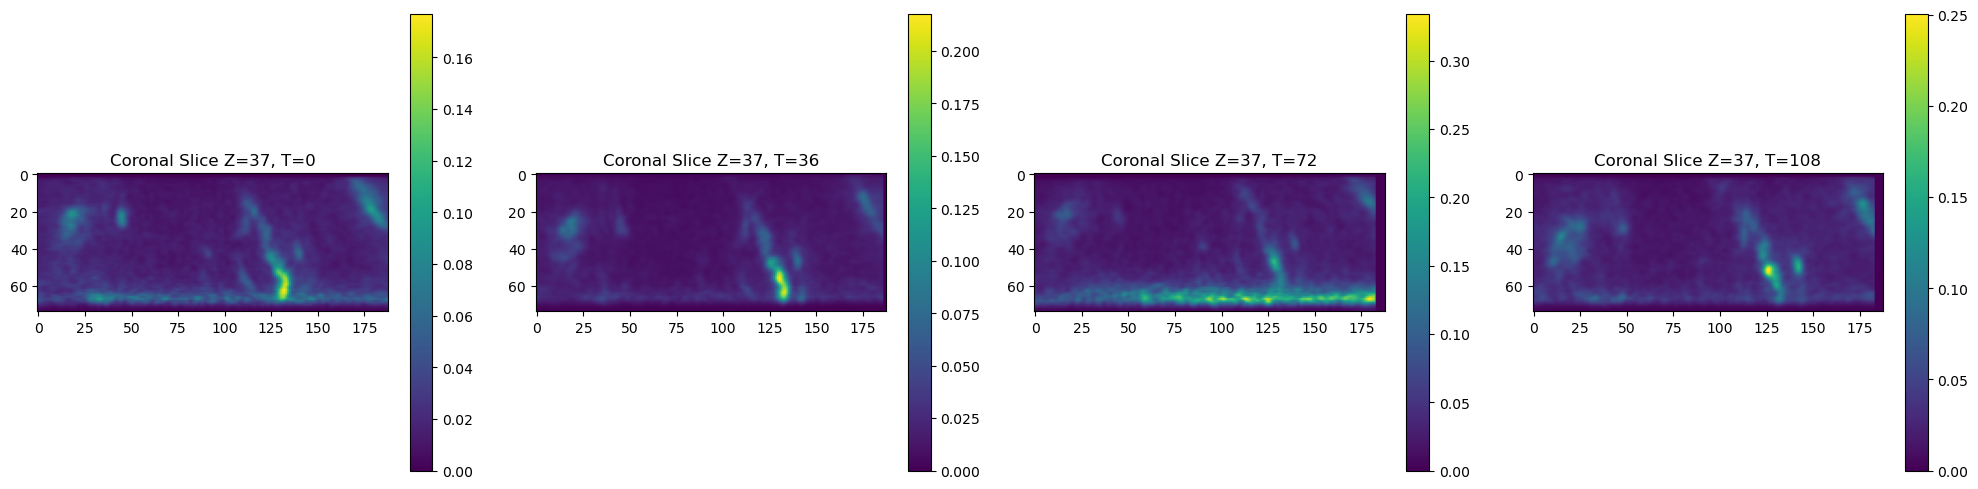

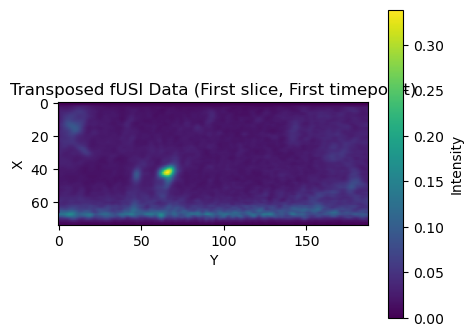

New fusi_data shape: (188, 344, 74, 109)


In [10]:
# Plot the data, make sure nothing crazy is happening, in particular, as I am mocking a 3D scan to play nice with nilearn, we need to make sure the data is in the right shape and the info across the second dimension is simply a copy
import matplotlib.pyplot as plt
import numpy as np

# Visualize to ensure we are getting what we think we should be getting!
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20, 5))  # 1 row, 4 columns for T dimension
z_dim = int(fusi_data.shape[2]/2)  # Set z_dim to half of the Z dimension
for t_index, t_dim in enumerate(np.linspace(0, fusi_data.shape[3] - 1, 4, dtype=int)):  # Sample 4 equally spaced indices along the T dimension
    ax = axs[t_index]  # Select the subplot for the current column
    img_plot = ax.imshow(np.flip(fusi_data[:,z_dim,:,t_dim].transpose(), axis=1))

    ax.set_title(f'Coronal Slice Z={z_dim}, T={t_dim}')
    plt.colorbar(img_plot, ax=ax)

plt.tight_layout()
plt.show()

# After validating that the plot is correct, transform fusi_data
fusi_data_transposed = np.transpose(fusi_data, (2, 1, 0, 3))
# Visualize the transposed fUSI data
plt.figure(figsize=(5, 4))
plt.imshow(fusi_data_transposed[:, 28, :, 1], cmap='viridis')
plt.colorbar(label='Intensity')
plt.title('Transposed fUSI Data (First slice, First timepoint)')
plt.xlabel('Y')
plt.ylabel('X')
plt.show()

# Optionally, you can add a print statement to confirm the new shape
print(f"New fusi_data shape: {fusi_data.shape}")

Data shape is (188, 344, 74)


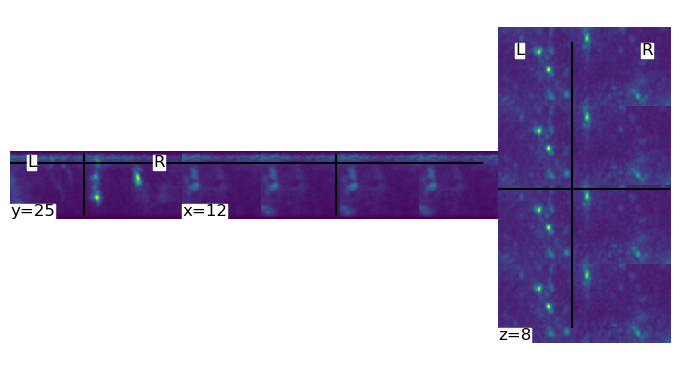

In [11]:
# quick sanity check that conversion to nifti / save/load are working.
from nilearn import image
import nibabel as nib

affine=np.diag([.15,.15,.15,0])
pd=np.array(fusi_data[:,:,:,0])
nifti_img = nib.Nifti1Image(pd, affine)
nifti_img.to_filename(dm.fUSI_data_path/"fUSi_data.nii.gz")
tmp=image.load_img(dm.fUSI_data_path/"fUSi_data.nii.gz")
print(f'Data shape is {tmp.shape}')
plotting.plot_img(tmp)

In [12]:
from nilearn.signal import butterworth


affine=np.diag([.15,.15,.15,0])
# pd=np.array(fusi_data)
def boxcar_smooth(data, window_size):
    if window_size>0:
        temp_smooth_data = np.copy(data)
        for t in range(data.shape[3]):
            start_index = max(0, t - window_size // 2)
            end_index = min(data.shape[3], t + window_size // 2 + 1)
            smoothed_data[:, :, :, t] = np.mean(data[:, :, :, start_index:end_index], axis=3)
    else:
        smoothed_data=data
    return smoothed_data

window_size = 0  # Number of time points for smoothing
pd = boxcar_smooth(fusi_data, window_size)
nifti_img = nib.Nifti1Image(pd, affine)
nifti_img.to_filename(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data=image.load_img(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data.shape

(188, 344, 74, 109)

In [13]:
# Define the smoothing function
def temporal_smoothing(data, window_size):
    # Initialize the smoothed data array
    temp_smooth_data = np.zeros_like(data)
    
    # Apply the smoothing
    for t in range(data.shape[3]):
        start_index = max(0, t - window_size // 2)
        end_index = min(data.shape[3], t + window_size // 2 + 1)
        temp_smooth_data[:, :, :, t] = np.mean(data[:, :, :, start_index:end_index], axis=3)
    
    return temp_smooth_data

# Set the window size for smoothing
smoothing_window_size = 1  # This can be adjusted as needed

# Apply the smoothing function to the data
temp_smooth_data = temporal_smoothing(fusi_data, smoothing_window_size)

# Convert the smoothed data back into a Nifti image
smoothed_nifti_img = nib.Nifti1Image(temp_smooth_data, affine)
smoothed_nifti_img.to_filename(dm.fUSI_data_path/"smoothed_fUSi_data.nii.gz")
smoothed_nifti_data=image.load_img(dm.fUSI_data_path/"smoothed_fUSi_data.nii.gz")
smoothed_nifti_data.shape


(188, 344, 74, 109)

In [14]:
contrast_matrix = np.eye(design_matrix.shape[1])
basic_contrasts = {
    column: contrast_matrix[i]
    for i, column in enumerate(design_matrix.columns)
}
basic_contrasts

{'stimulus_onset': array([1., 0., 0., 0., 0., 0.]),
 'tx': array([0., 1., 0., 0., 0., 0.]),
 'ty': array([0., 0., 1., 0., 0., 0.]),
 'rot': array([0., 0., 0., 1., 0., 0.]),
 'drift_1': array([0., 0., 0., 0., 1., 0.]),
 'constant': array([0., 0., 0., 0., 0., 1.])}

In [15]:
from nilearn.glm.first_level import FirstLevelModel
print("Fitting a GLM")
fmri_glm = FirstLevelModel(minimize_memory=False,mask_img=False,smoothing_fwhm=smoothing_fwhm,standardize=True)
fmri_glm = fmri_glm.fit(nifti_data, design_matrices=design_matrix)

Fitting a GLM


Computing contrasts
	contrast id: stimulus_onset
Saved z_map_activation.mat to /Users/clairenastaskin/data/2024-10-23/UCLA-008/Functional_runs/run-01/acquisitions/seq-IQ_3D_2cmto3cm_Depth_5MHz_1a_3c_200loops_-1Gain_2rp/power_doppler


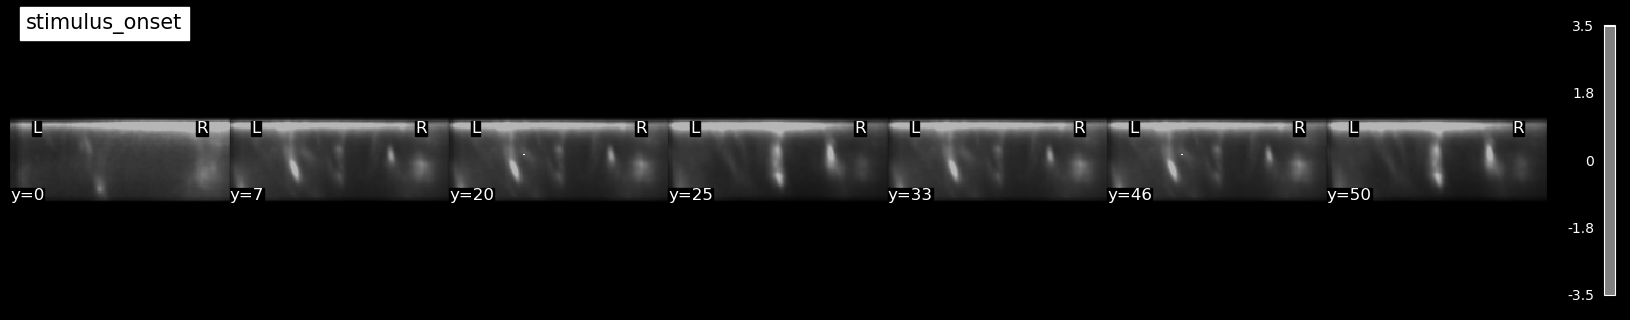

	contrast id: tx


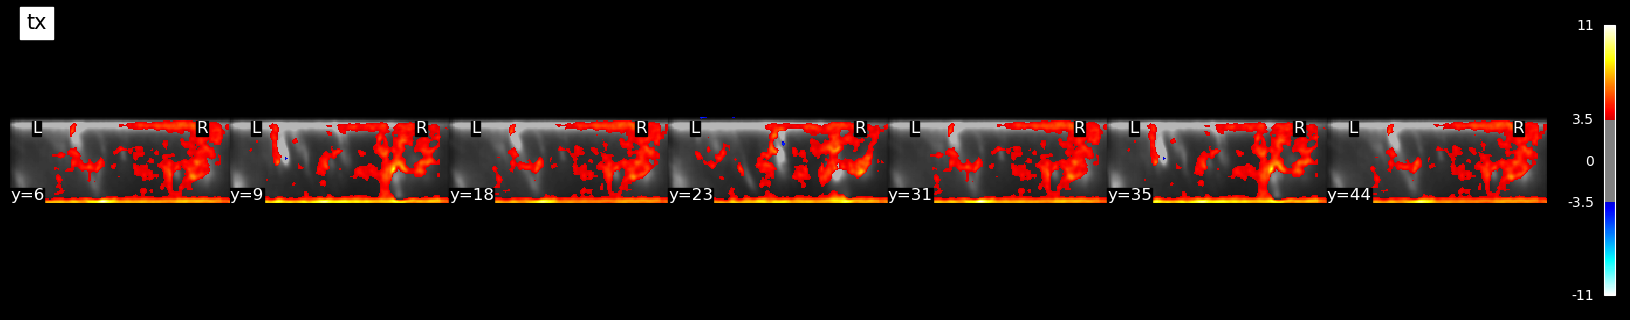

	contrast id: ty


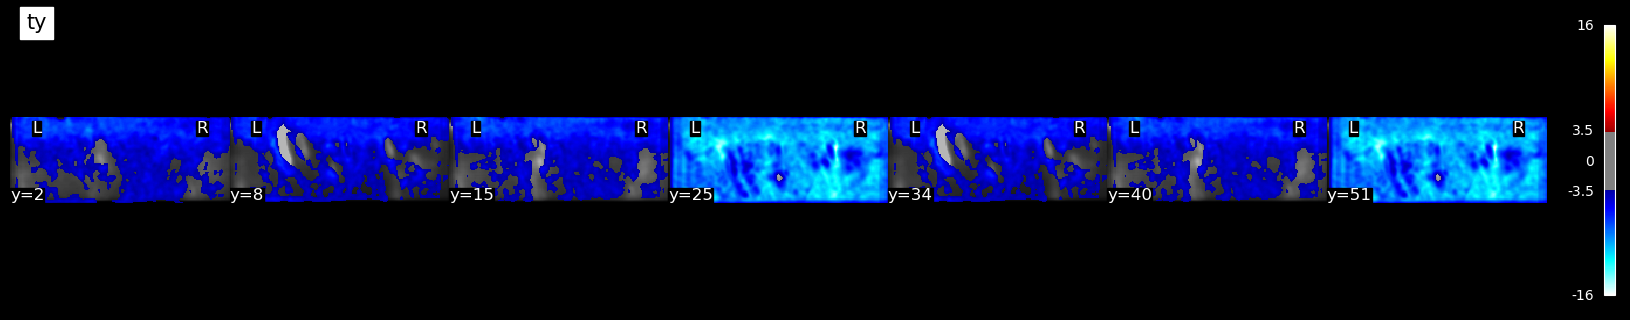

	contrast id: rot


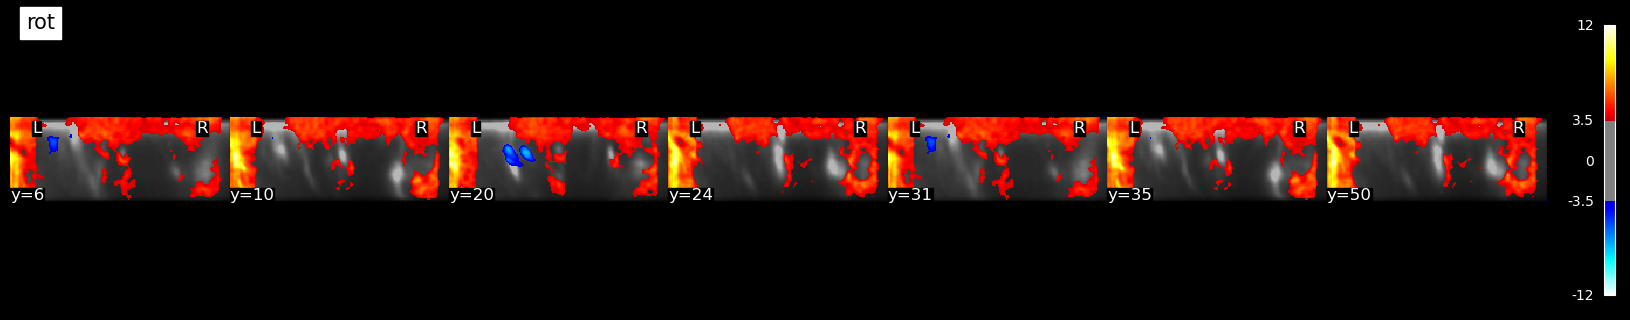

	contrast id: drift_1


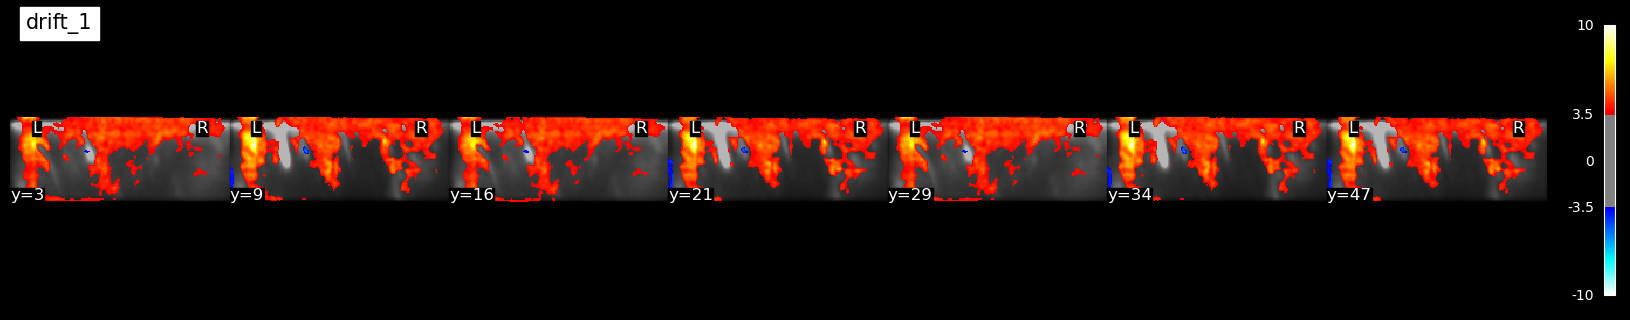

	contrast id: constant


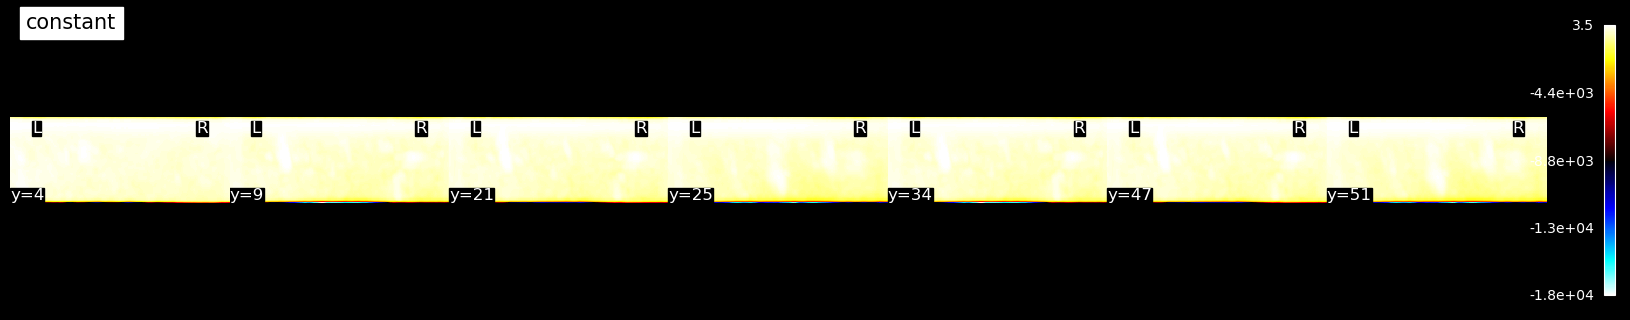

In [16]:
from nilearn import plotting
from nilearn.image import concat_imgs, mean_img, resample_img, new_img_like

# nifti_data = smoothed_nifti_data # if we want to use the smooth data

print("Computing contrasts")
mean_image = mean_img(nifti_data) # mean doppler image

# Increase the intensity of the mean_image (doppler)
data = mean_image.get_fdata()
scaled_data = (data - data.min()) / (data.max() - data.min())  # Normalize the data to 0-1
enhanced_data = scaled_data * 4  # Scale the normalized data to increase intensity
enhanced_data[enhanced_data > 1] = 1  # Clip values to maintain them within [0, 1]

# Create a new Nifti image with the enhanced data
enhanced_mean_image = new_img_like(mean_image, enhanced_data)

# Iterate on contrasts
for i, (contrast_id, contrast_val) in enumerate(basic_contrasts.items()):
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat")
    
    # Save z_map as z_map_activation for the first contrast
    if i == 0:
        z_map_data = z_map.get_fdata()
        savemat(dm.power_doppler_path / "z_map_activation.mat", {'z_map': z_map_data})
        print(f"Saved z_map_activation.mat to {dm.power_doppler_path }")
    
    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fMRI image
    # a threshold of 3.0 is used, more sophisticated choices are possible
    
    plotting.plot_stat_map(
        z_map,
        bg_img=enhanced_mean_image,
        threshold=3.5,        
        display_mode="y",        
        black_bg=True,        
        title=contrast_id,
    )
    plotting.show()

In [17]:
# Save the z_maps as .mat files

import nibabel as nib
from scipy.io import savemat
from pathlib import Path

# Assuming fmri_glm and basic_contrasts are already defined and used as shown previously
for contrast_id, contrast_val in basic_contrasts.items():
    print(f"Processing contrast id: {contrast_id}")
    # Compute the contrasts
    z_map = fmri_glm.compute_contrast(contrast_val, output_type="z_score")
    # Load the z_map data as an array
    z_map_data = z_map.get_fdata()
    # If you need a 2D array combining all slices (e.g., 177x198), you can reshape:
    if z_map_data.shape[2] * z_map_data.shape[1] == 198:  # Example condition for reshaping
        combined_slices = z_map_data.reshape(z_map_data.shape[0], -1)
        save_path = Path(base_path) / 'acquisitions' / sequence / 'functional_analysis' / f"{contrast_id}_z_map_combined.mat"
        savemat(save_path, {'z_map': combined_slices})
        print(f"Saved {save_path}")

Processing contrast id: stimulus_onset
Processing contrast id: tx
Processing contrast id: ty
Processing contrast id: rot
Processing contrast id: drift_1
Processing contrast id: constant


# Plot time series for ROI response and stimulus regressor

Identify ROIs using an automated clustering approach. Extract the time series for each ROI. Plot the time series and corresponding locations.



In [18]:
from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table

num_locations=3 # How many ROIs to visualize

# Find ROIs by identifying the locations that show a significant response to the stimulus
mean_image = mean_img(nifti_data)
z_map = fmri_glm.compute_contrast(basic_contrasts['stimulus_onset'], output_type="stat")
# z_map = fmri_glm.compute_contrast(basic_contrasts['drift_1'], output_type="stat")
table = get_clusters_table(z_map, stat_threshold=2.5, cluster_threshold=10)
table.set_index("Cluster ID", drop=True)
table.head()

# get the num_locations largest clusters' max x, y, and z coordinates
coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values
# coords = np.vstack([coords, [10.45000061,  0.        , 18.40000045]])

print(coords)



# Now use the ROIs to extract the time series 
masker = NiftiSpheresMasker(coords)
standardize="zscore" # zscore psc
masker = NiftiSpheresMasker(
    coords,
    radius=smoothing_fwhm,
    detrend=True,
    standardize="psc", # standardize, zscore psc
    low_pass=0.05,
    # high_pass=0.01,
    t_r=3,
    memory_level=1,
    verbose=0,
)

real_timeseries = masker.fit_transform(nifti_data)
# predicted_timeseries = masker.fit_transform(fmri_glm.predicted[0])
predicted_timeseries = np.tile(design_matrix['stimulus_onset'].values, (real_timeseries.shape[1], 1)).T


[[ 9.60000038 20.40000081  6.15000024]
 [ 9.60000038 46.20000184  6.15000024]
 [ 9.45000038 33.30000132  6.15000024]]


In [19]:
from sklearn.metrics import r2_score

# Calculate the R-squared value for each ROI
r_squared_values = []
for i in range(real_timeseries.shape[1]):
    r_squared = r2_score(real_timeseries[:, i], predicted_timeseries[:, i])
    r_squared_values.append(r_squared)

# Display the R-squared values
print("R-squared values for each ROI:")
for idx, r2 in enumerate(r_squared_values):
    print(f"ROI {idx + 1}: {r2:.3f}")

R-squared values for each ROI:
ROI 1: 0.008
ROI 2: 0.008
ROI 3: 0.012


NameError: name 'events' is not defined

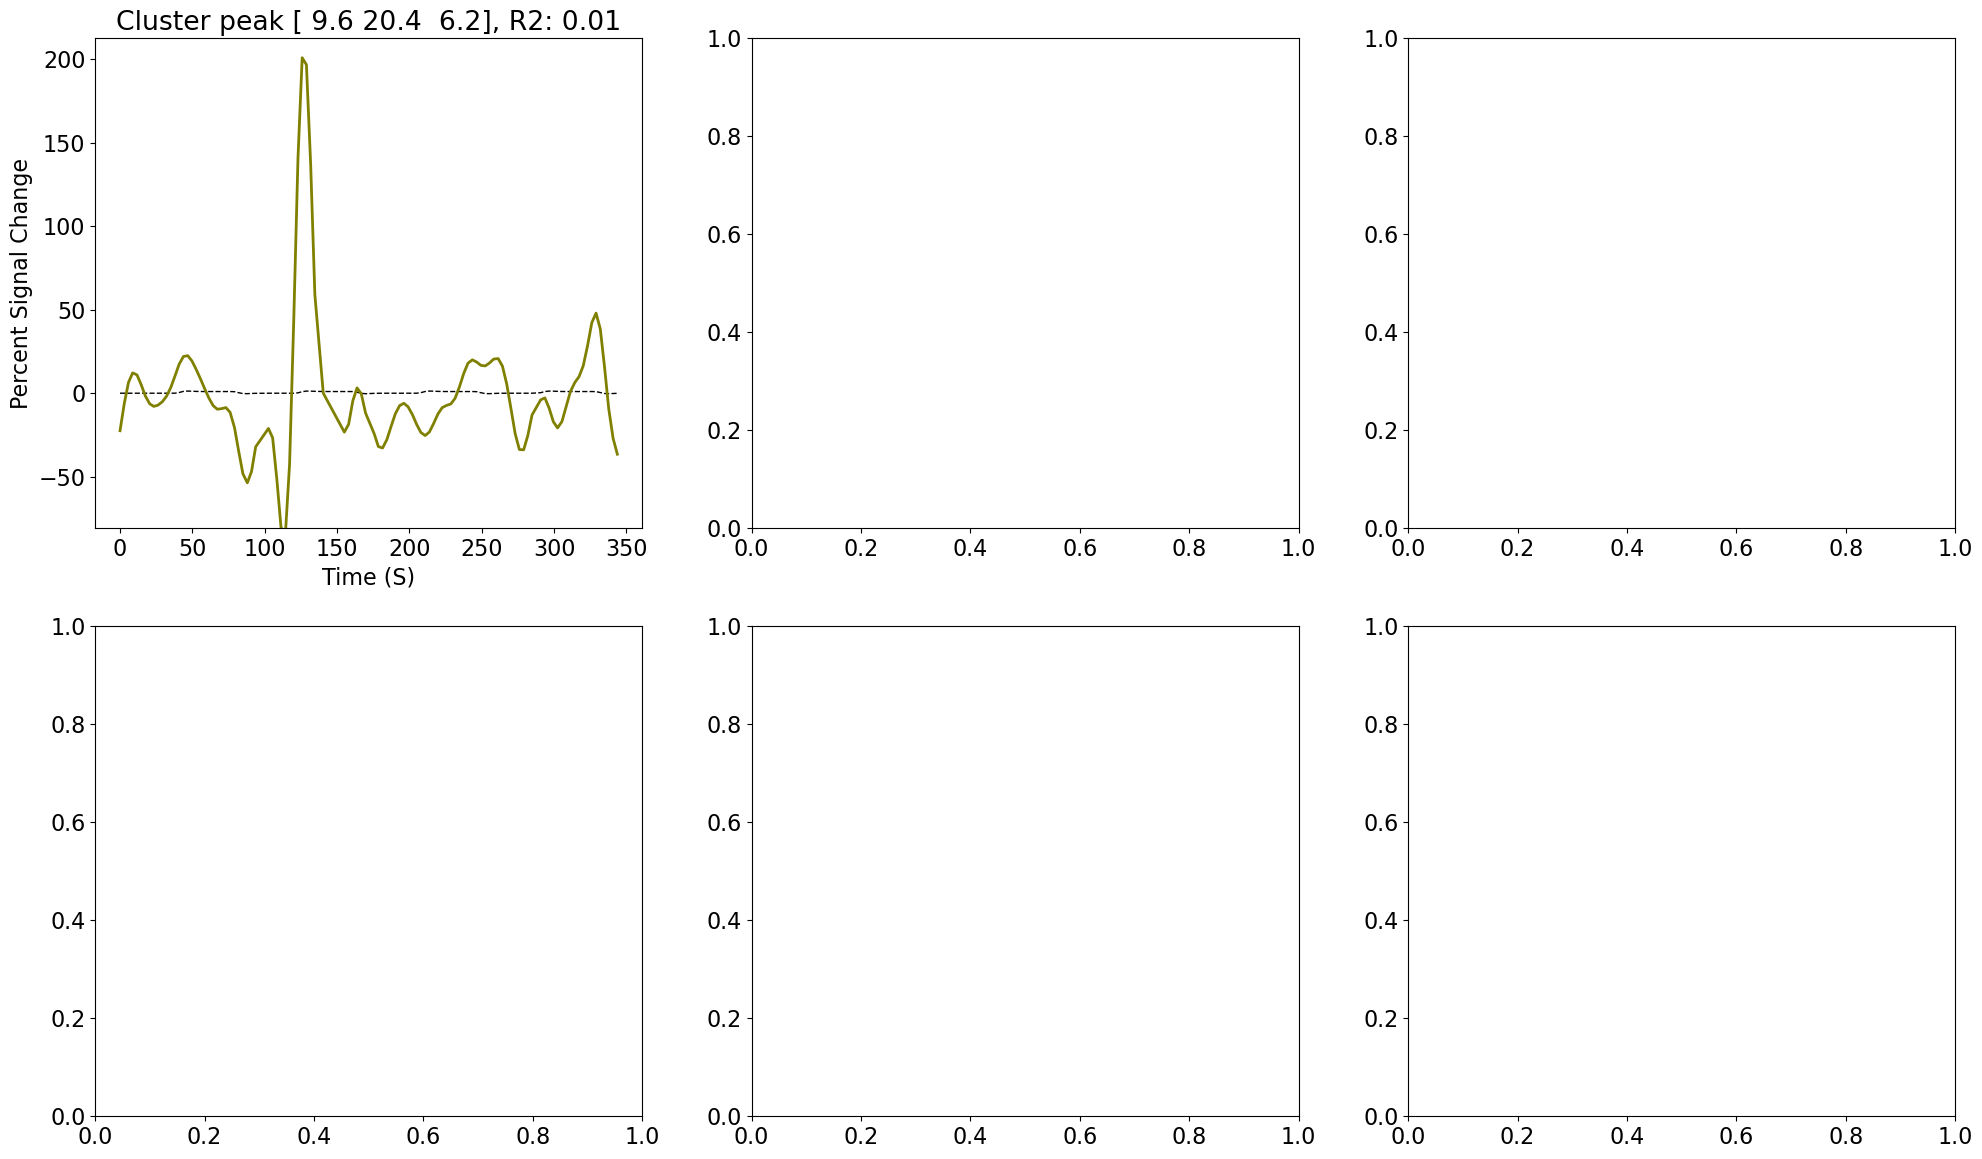

In [20]:
import matplotlib.pyplot as plt
from nilearn import plotting
import matplotlib as mpl

# Assuming all necessary variables like `real_timeseries`, `predicted_timeseries`, `fusi_info`, `events`, etc. are already defined
mpl.rcParams.update({'font.size': 16})  # You can adjust the size as needed

colors = ["olive","green", "navy", "purple", "magenta",  "teal"]
N = real_timeseries.shape[-1]
fig1, axs1 = plt.subplots(2, N, figsize=(24, 14))

mx = real_timeseries.max() + 0.05 * real_timeseries.max()
mn = real_timeseries.min() - 0.05 * real_timeseries.min()

for i in range(N):
    # Time series plot
    axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}")
    axs1[0, i].plot(fusi_info['Experiment Time'], predicted_timeseries[:, i], c="k", ls="--", lw=1)
    axs1[0, i].plot(fusi_info['Experiment Time'], real_timeseries[:, i], c=colors[i], lw=2)
    axs1[0, i].set_xlabel("Time (S)")
    axs1[0, i].set_ylim(mn, mx)
    if masker.standardize == "psc":
        axs1[0, i].set_ylabel('Percent Signal Change')
    else:
        axs1[0, i].set_ylabel("Signal intensity")

    # Highlight regions of time described by the onsets and durations in events
    for onset, duration in zip(events['onset'], events['duration']):
        axs1[0, i].axvspan(onset + event_time_offset, onset + duration + event_time_offset, color='gray', alpha=0.5)

    # Statistical map plot
    display = plotting.plot_stat_map(
        z_map,
        cut_coords=coords[i],
        threshold=3,
        figure=fig1,
        axes=axs1[1, i],
        display_mode="ortho",
        colorbar=False,
        bg_img=mean_image,
    )
    display.add_markers([coords[i]], marker_color=colors[i], marker_size=200)

plt.tight_layout()
plt.show()

In [ ]:
onsets = events['onset'].values
durations = events['duration'].values
real_timeseries = real_timeseries.reshape(real_timeseries.shape[0], real_timeseries.shape[1], 1)

from scipy.io import savemat

# Assuming 'onsets' and 'durations' are already defined as numpy arrays
savemat(base_path / 'acquisitions' / sequence / 'functional_analysis' / 'onsets.mat', {'onsets': onsets})
savemat(base_path / 'acquisitions' / sequence / 'functional_analysis' / 'durations.mat', {'durations': durations})
savemat(base_path / 'acquisitions' / sequence / 'functional_analysis' / 'real_timeseries.mat', {'real_timeseries': real_timeseries})

from scipy.io import savemat



OSError: Reader needs file name or open file-like object

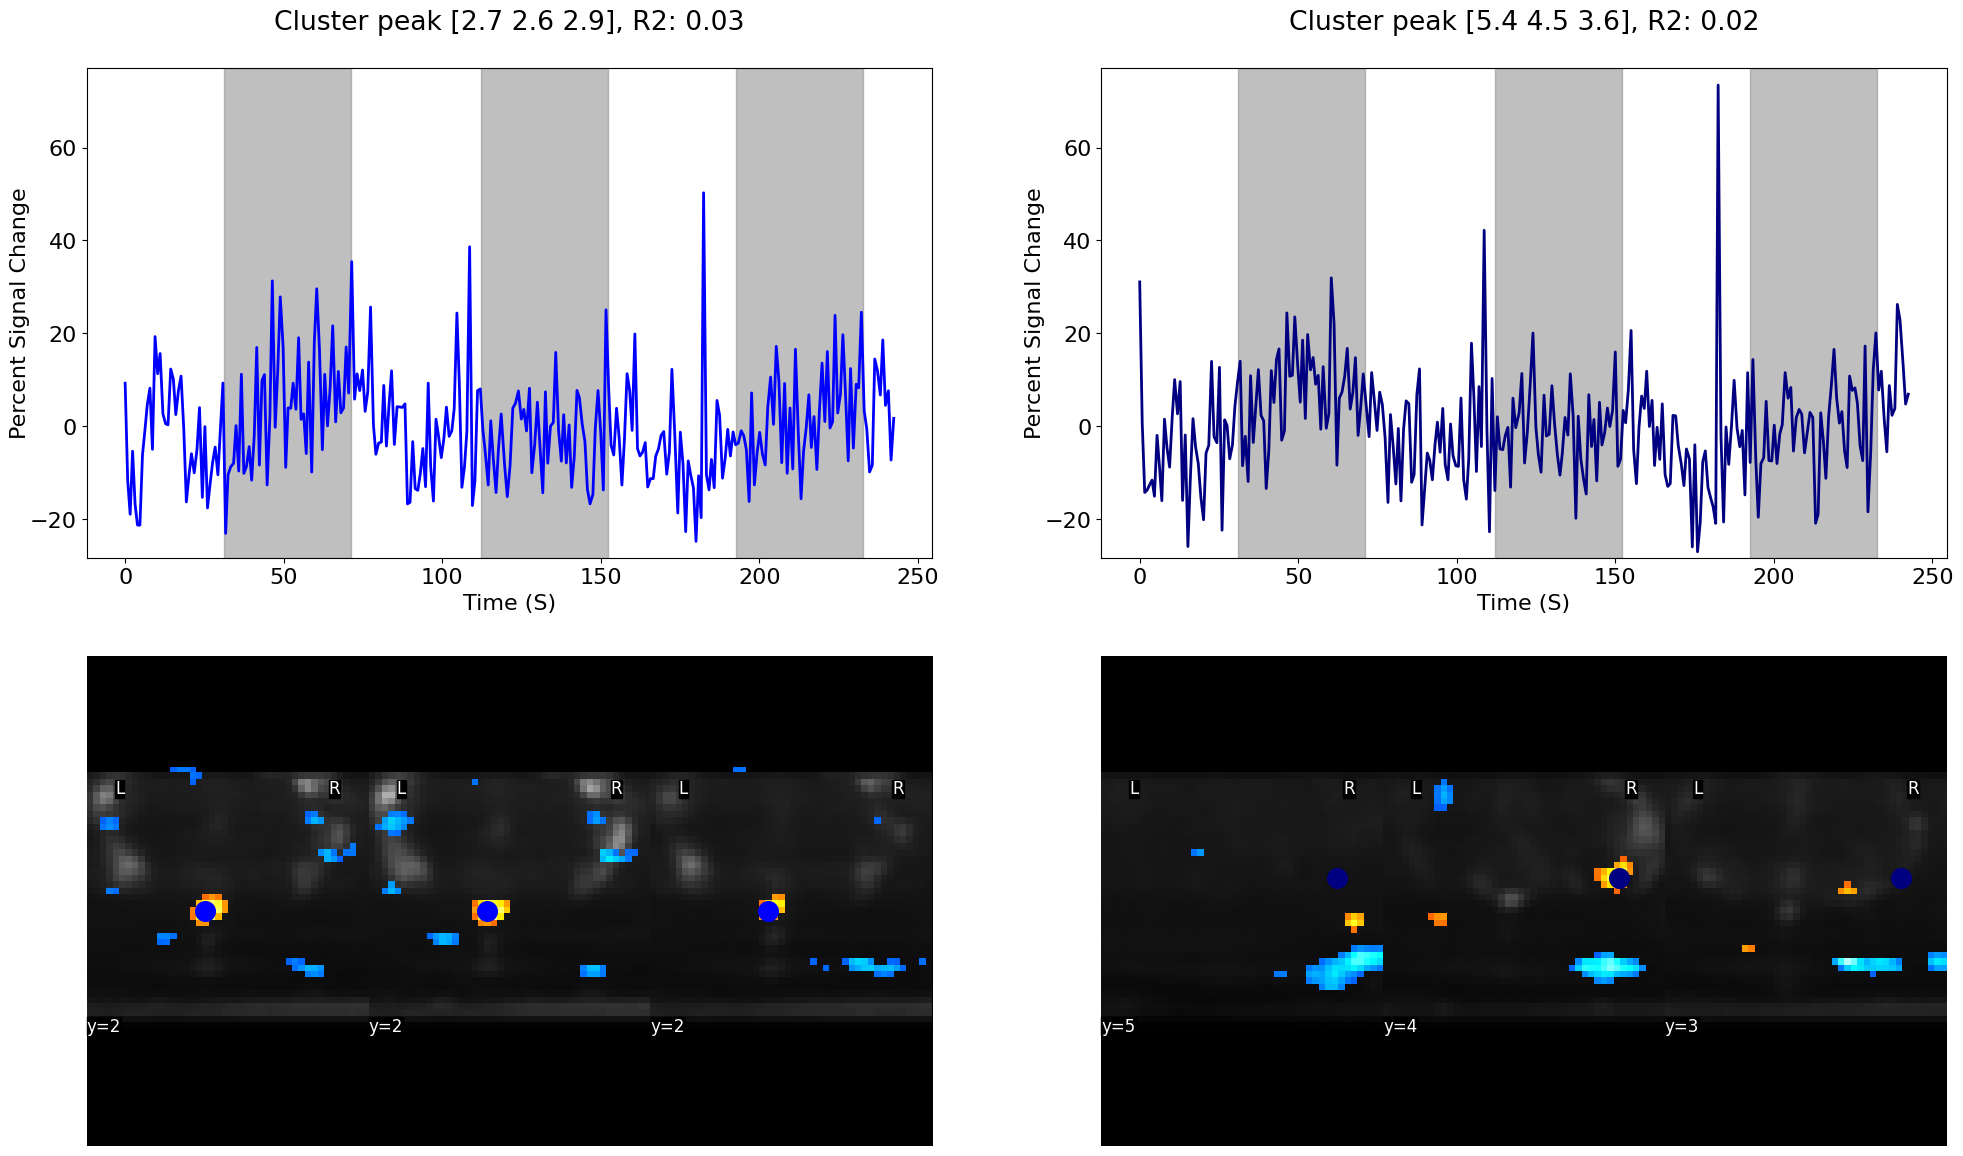

In [ ]:
# And finaly, plot the time series for each ROI and the corresponding location of each ROI
# colors for each of the clusters
colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# plot the time series and corresponding locations
N=real_timeseries.shape[-1]
fig1, axs1 = plt.subplots(2, N)

# get plot limits, common across all axis
mx=real_timeseries.max()+0.05*real_timeseries.max()
mn=real_timeseries.min()+0.05*real_timeseries.min()

for i in range(N):
    # plotting time series
    axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}\n")
    if masker.standardize != "psc":
        axs1[0, i].plot(fusi_info['Experiment Time'], predicted_timeseries[:, i], c="k", ls="--", lw=1)
    # axs1[0, i].plot(fusi_info['Experiment Time'], predicted_timeseries[:, i], c="k", ls="--", lw=1)
    # axs1[0, i].plot(fusi_info['Experiment Time'], design_matrix['Stimulus on'], c="k", ls="--", lw=1)
    axs1[0, i].plot(fusi_info['Experiment Time'], real_timeseries[:, i], c=colors[i], lw=2)
    axs1[0, i].set_xlabel("Time (S)")

    if masker.standardize == "psc":
        axs1[0, i].set_ylabel('Percent Signal Change', labelpad=0)
    else:
        axs1[0, i].set_ylabel("Signal intensity", labelpad=0)

    # plotting image below the time series
    # Highlight regions of time described by the onsets and durations in events
    # Assuming 'events' is a DataFrame with columns 'onset' and 'duration' for stimulus events
    for onset, duration in zip(events['onset'], events['duration']):
        axs1[0, i].axvspan(onset+event_time_offset, onset + duration+event_time_offset, color='gray', alpha=0.5)
    
    roi_img = plotting.plot_stat_map(
        z_map,
        cut_coords=coords[i],
        threshold=3,
        figure=fig1,
        axes=axs1[1, i],
        display_mode="y",
        colorbar=False,
        bg_img=mean_image,
    )
    
    axs1[0, i].set_ylim(mn, mx)
    roi_img.add_markers([coords[i]], colors[i], 200)
fig1.set_size_inches(24, 14)

# fig1.savefig(dm.fUSI_data_path/f"ROI_time_series_{sequence}.png")

